In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(color_codes=True)                                 # To get the different different colors
pd.set_option('display.max_columns',None)                        # To display the max columns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,roc_auc_score,roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Read the package

data=pd.read_csv('telecom_customer_churn.csv')
data.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


**Data Preprocessing Part 1**

In [3]:
data.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [4]:
data.shape

(7043, 38)

In [5]:
# Customer_ID and Zip code are just a ID
# So that we can drop these columns

# Drop identifier column

data.drop(columns=['Customer ID','Zip Code'], inplace=True)
data.shape

(7043, 36)

In [6]:
# Check the number of unique value from all of the object datatype
data.select_dtypes(include='object').nunique()

Gender                       2
Married                      2
City                      1106
Offer                        5
Phone Service                2
Multiple Lines               2
Internet Service             2
Internet Type                3
Online Security              2
Online Backup                2
Device Protection Plan       2
Premium Tech Support         2
Streaming TV                 2
Streaming Movies             2
Streaming Music              2
Unlimited Data               2
Contract                     3
Paperless Billing            2
Payment Method               3
Customer Status              3
Churn Category               5
Churn Reason                20
dtype: int64

In [7]:
# Drop city column because it have a lot of unique values
data.drop(columns='City',inplace=True)
data.shape

(7043, 35)

**Exploratory Data Analysis**

In [244]:
cat_vars=data.select_dtypes(include='object').columns.tolist()
len(cat_vars)
# 21 categorical columns are there

21

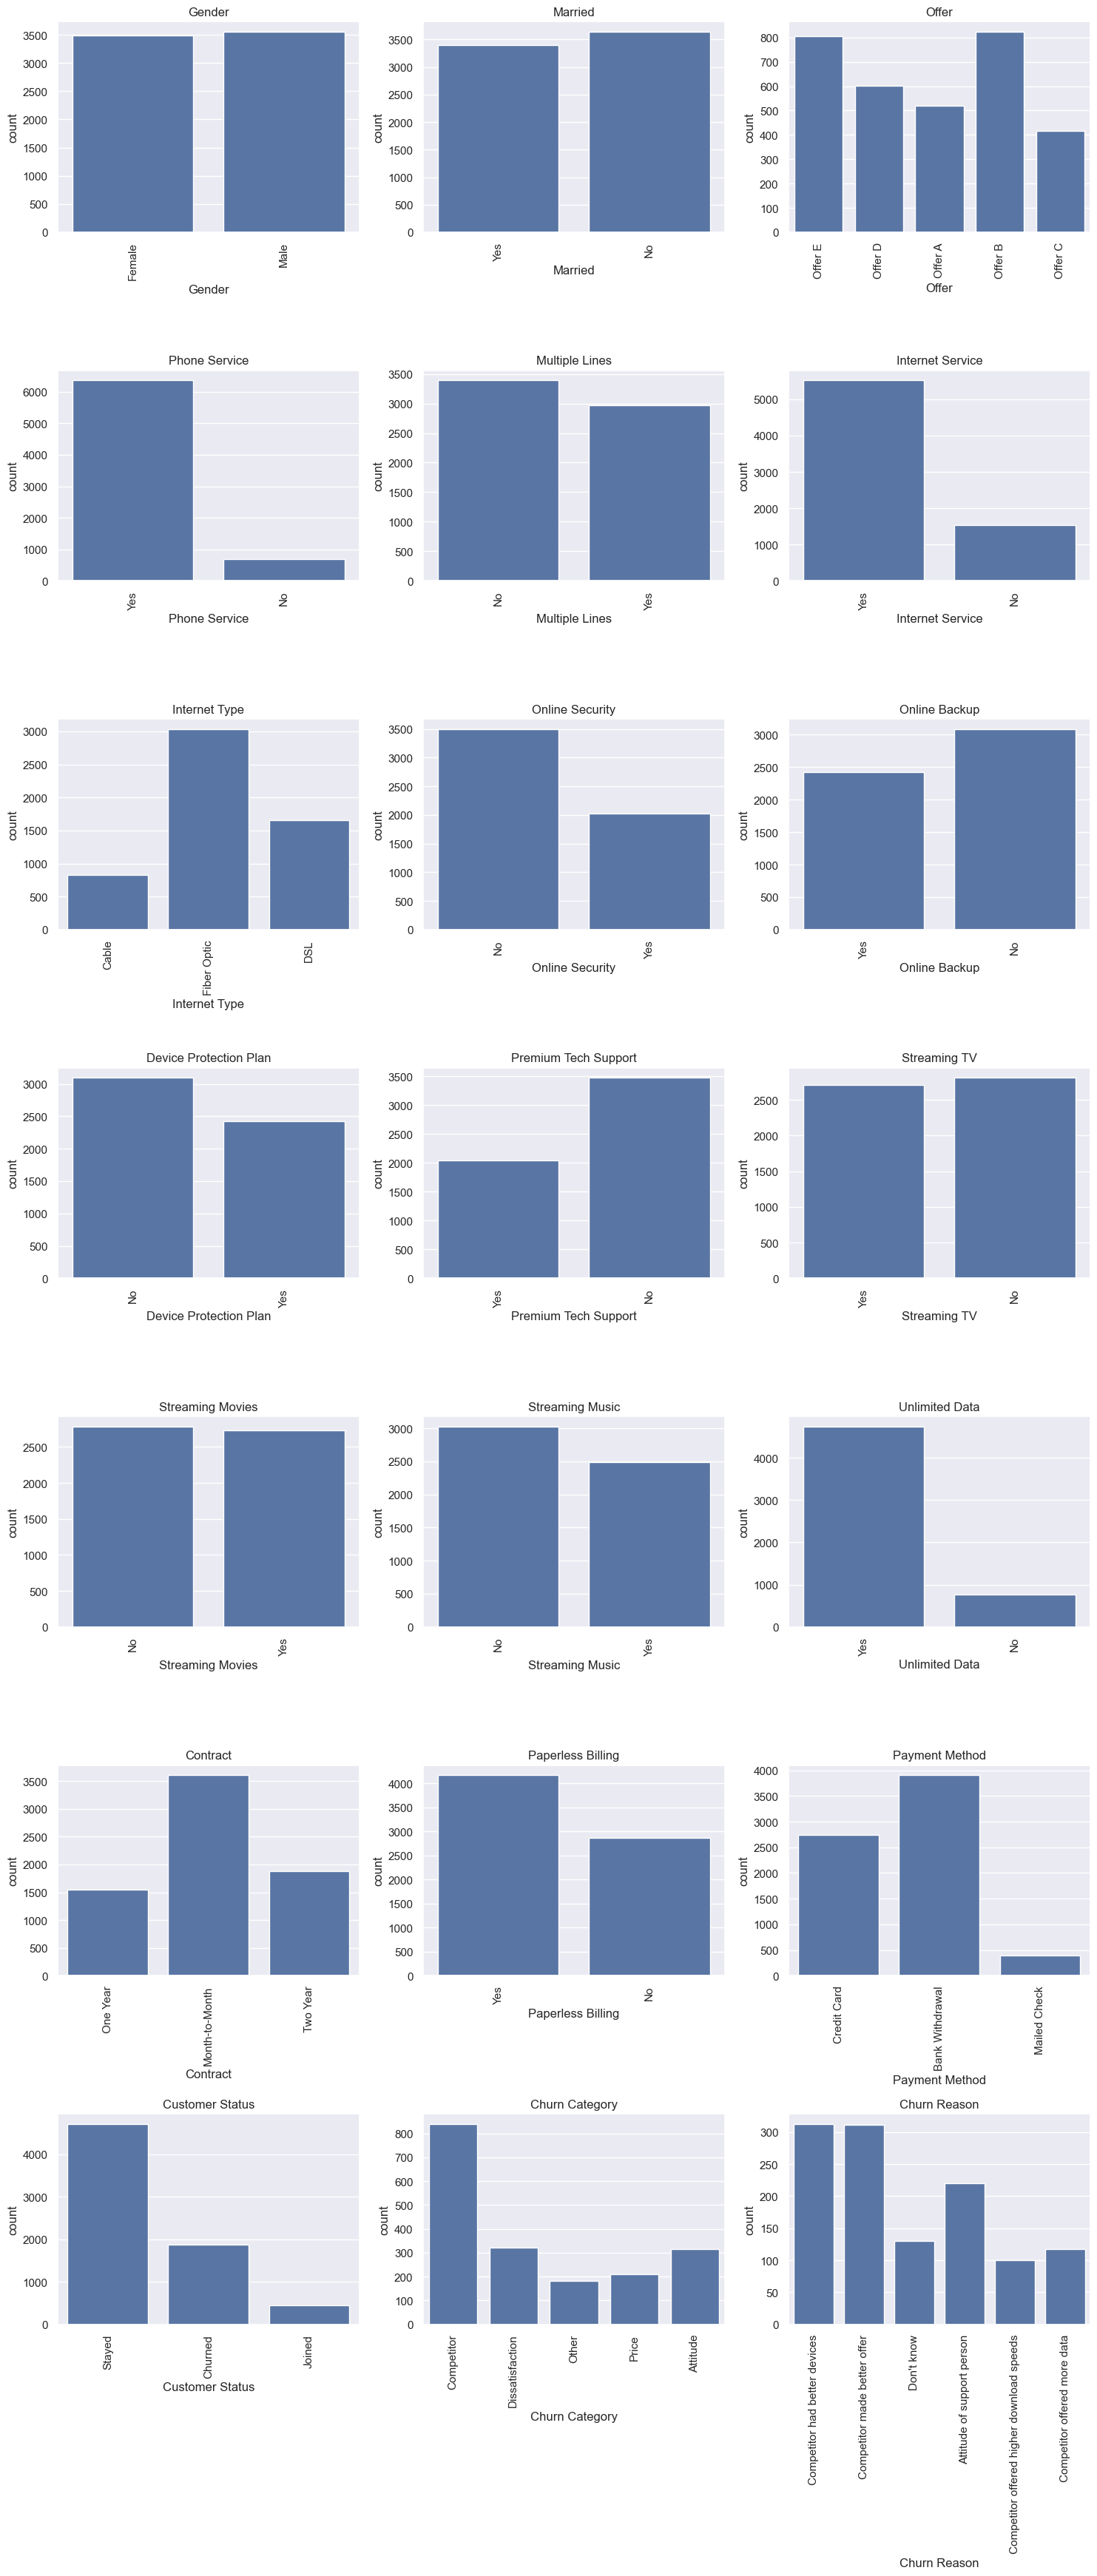

In [245]:
# Get the names of all columns with data type 'object' (categorical columns)
cat_vars=data.select_dtypes(include='object').columns.tolist()

# Create a figure with subplots
num_cols = len(cat_vars) 
num_rows =(num_cols + 2) // 3
fig, axs = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, 5*num_rows))
axs = axs.flatten()

# Create a counterplot for top 6 values of each categorical variables using Seaborn
for i, var in enumerate(cat_vars):
    top_values = data[var].value_counts().nlargest(6).index
    filtered_data =data[data[var].isin(top_values)]
    sns.countplot(x=var, data=filtered_data, ax=axs[i])
    axs[i].set_title(var)
    axs[i].tick_params(axis='x', rotation=90)

# Remove any extra empty subplot if needed
if num_cols < len(axs):
    for i in range(num_cols, len(axs)):
        fig.delaxes(axs[i])

# Adjust spacing between subplots
fig.tight_layout()

# Show plot
plt.show()

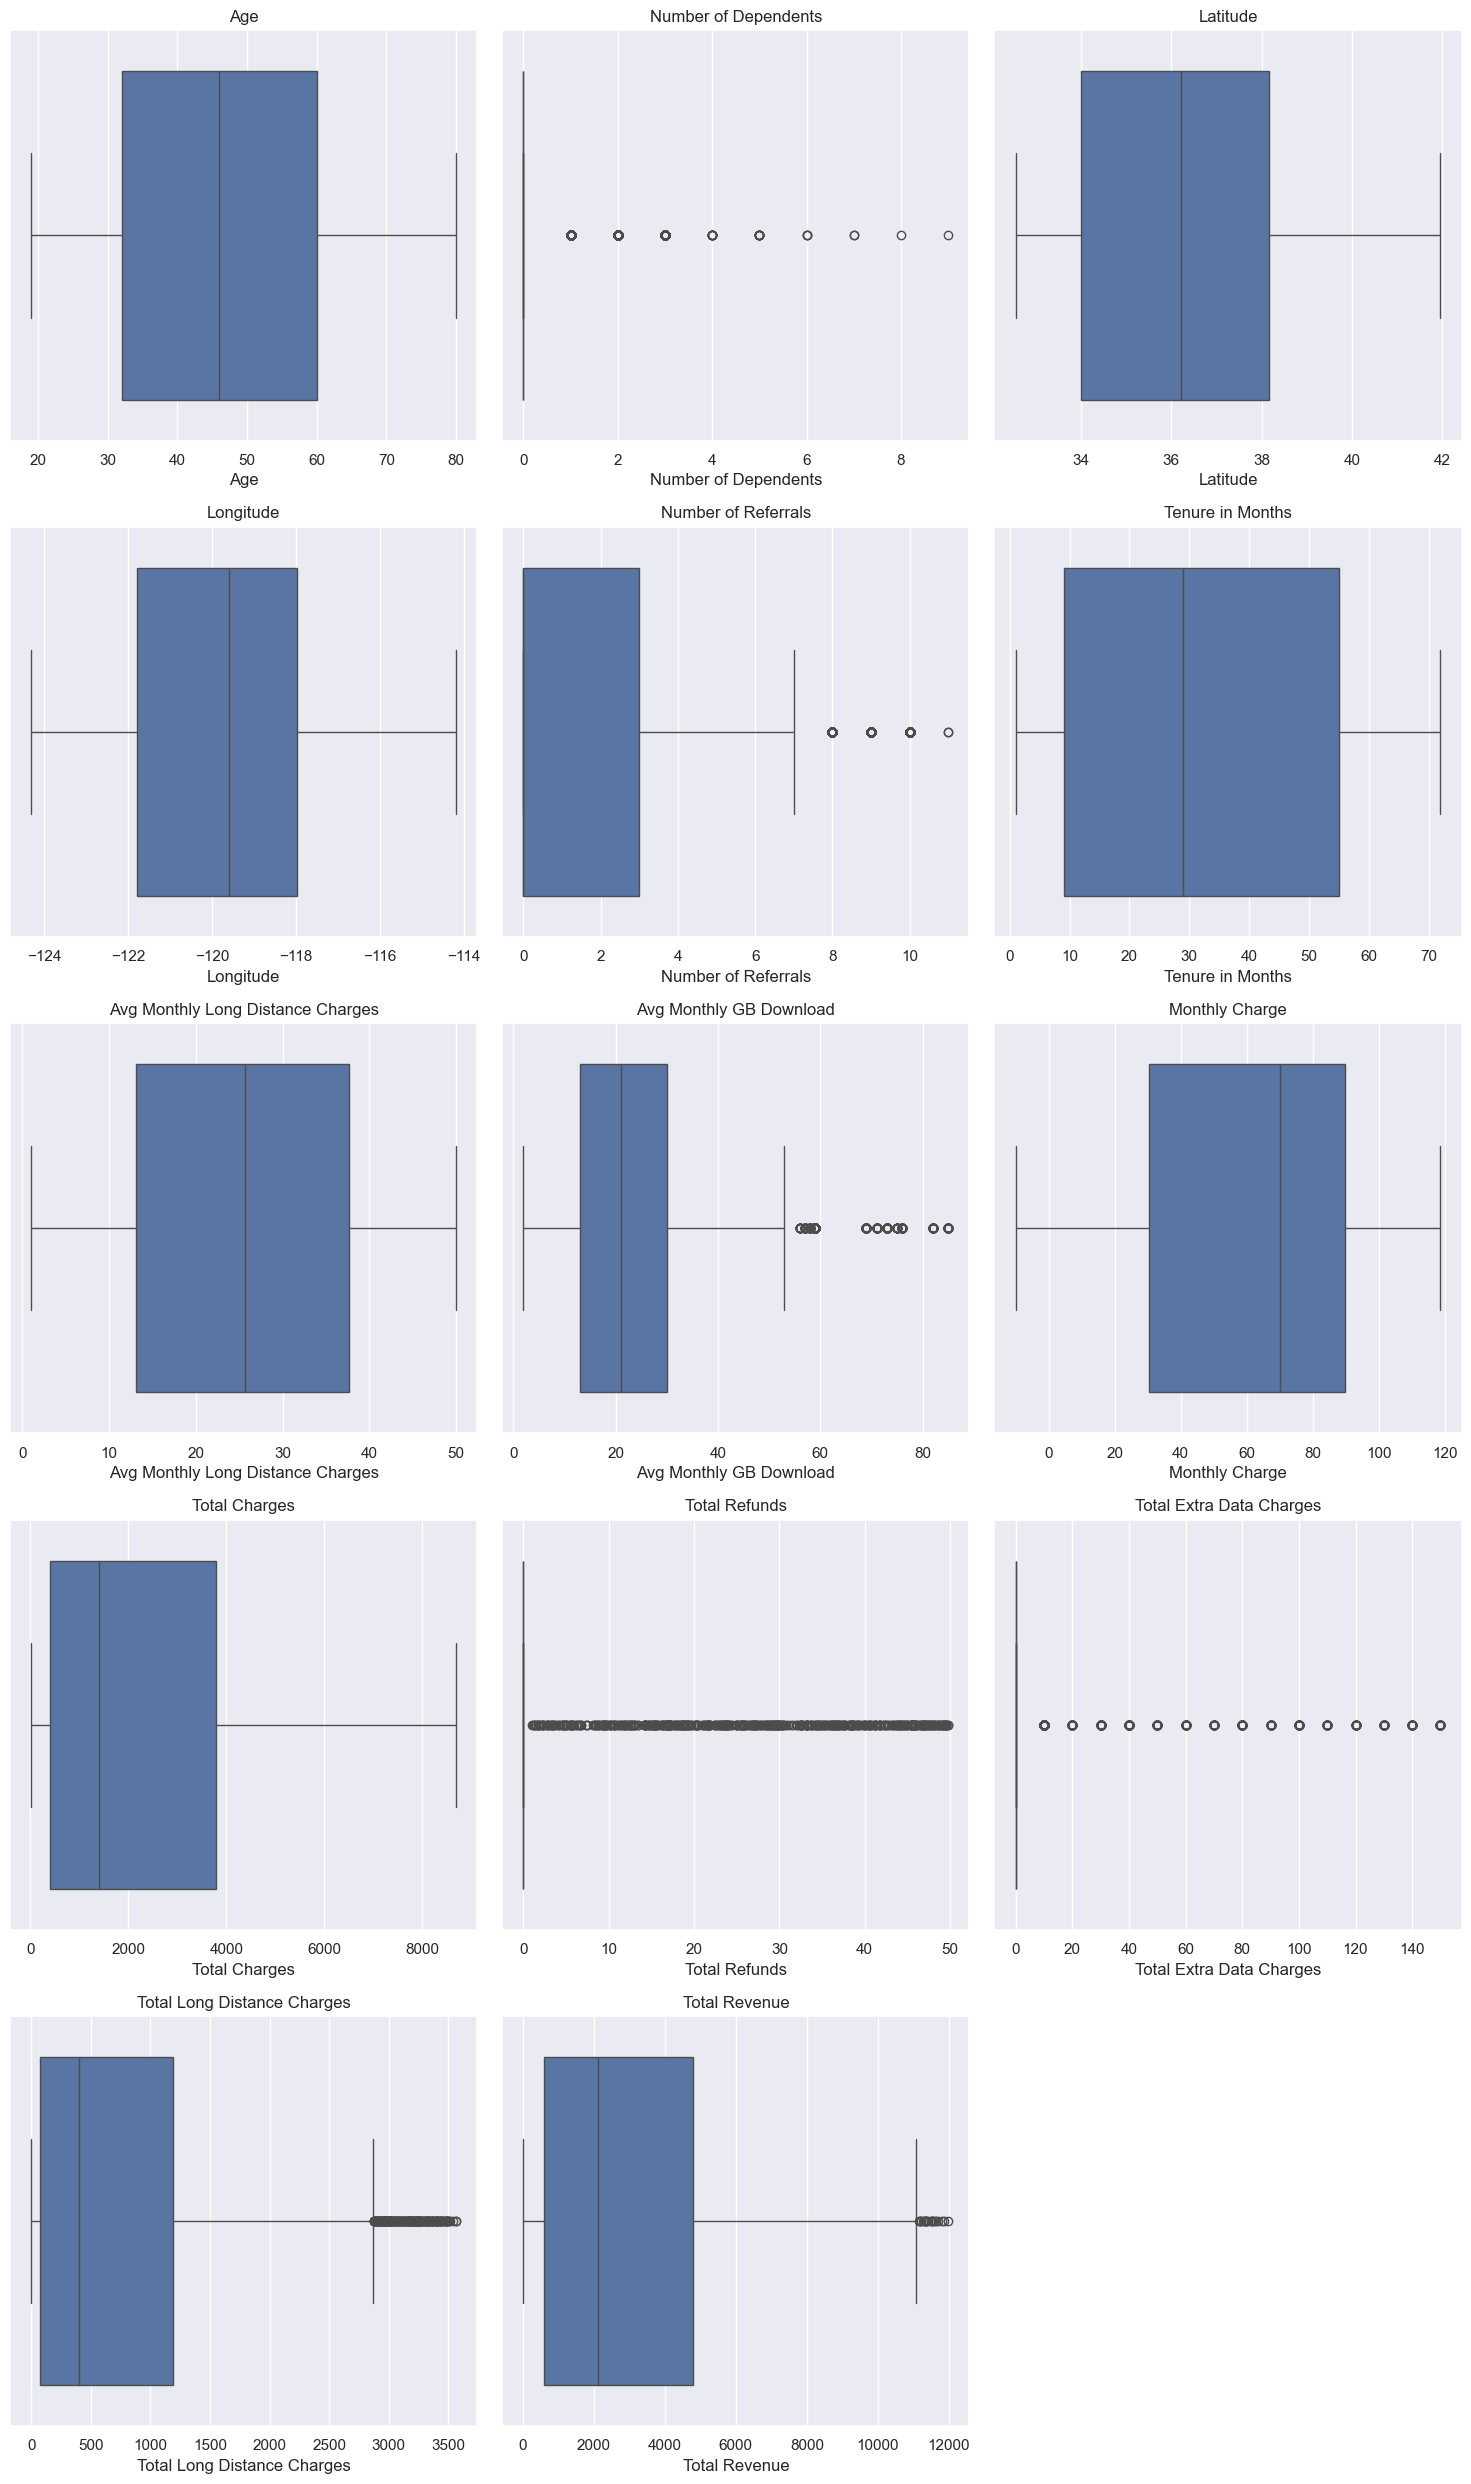

In [246]:
# Get the names of all the columns with data type " int " or "float"\
num_vars = data.select_dtypes(include=['int','float']).columns.tolist()

# Create w subplot with subplots
num_cols = len(num_vars)
num_rows = (num_cols + 2)//3
fig, axs = plt.subplots(nrows=num_rows, ncols=3, figsize=(15,5*num_rows))
axs = axs.flatten()

# create a box plot for each numerical variables using seaborn
for i, var in enumerate(num_vars):
    sns.boxplot(x=data[var], ax=axs[i])
    axs[i].set_title(var)

# Remove any extra empty subplots if needed
if num_cols < len(axs):
    for i in range(num_cols, len(axs)):
        fig.delaxes(axs[i])

# Adjust spacing between subplots
fig.tight_layout()

# Show plot
plt.show()

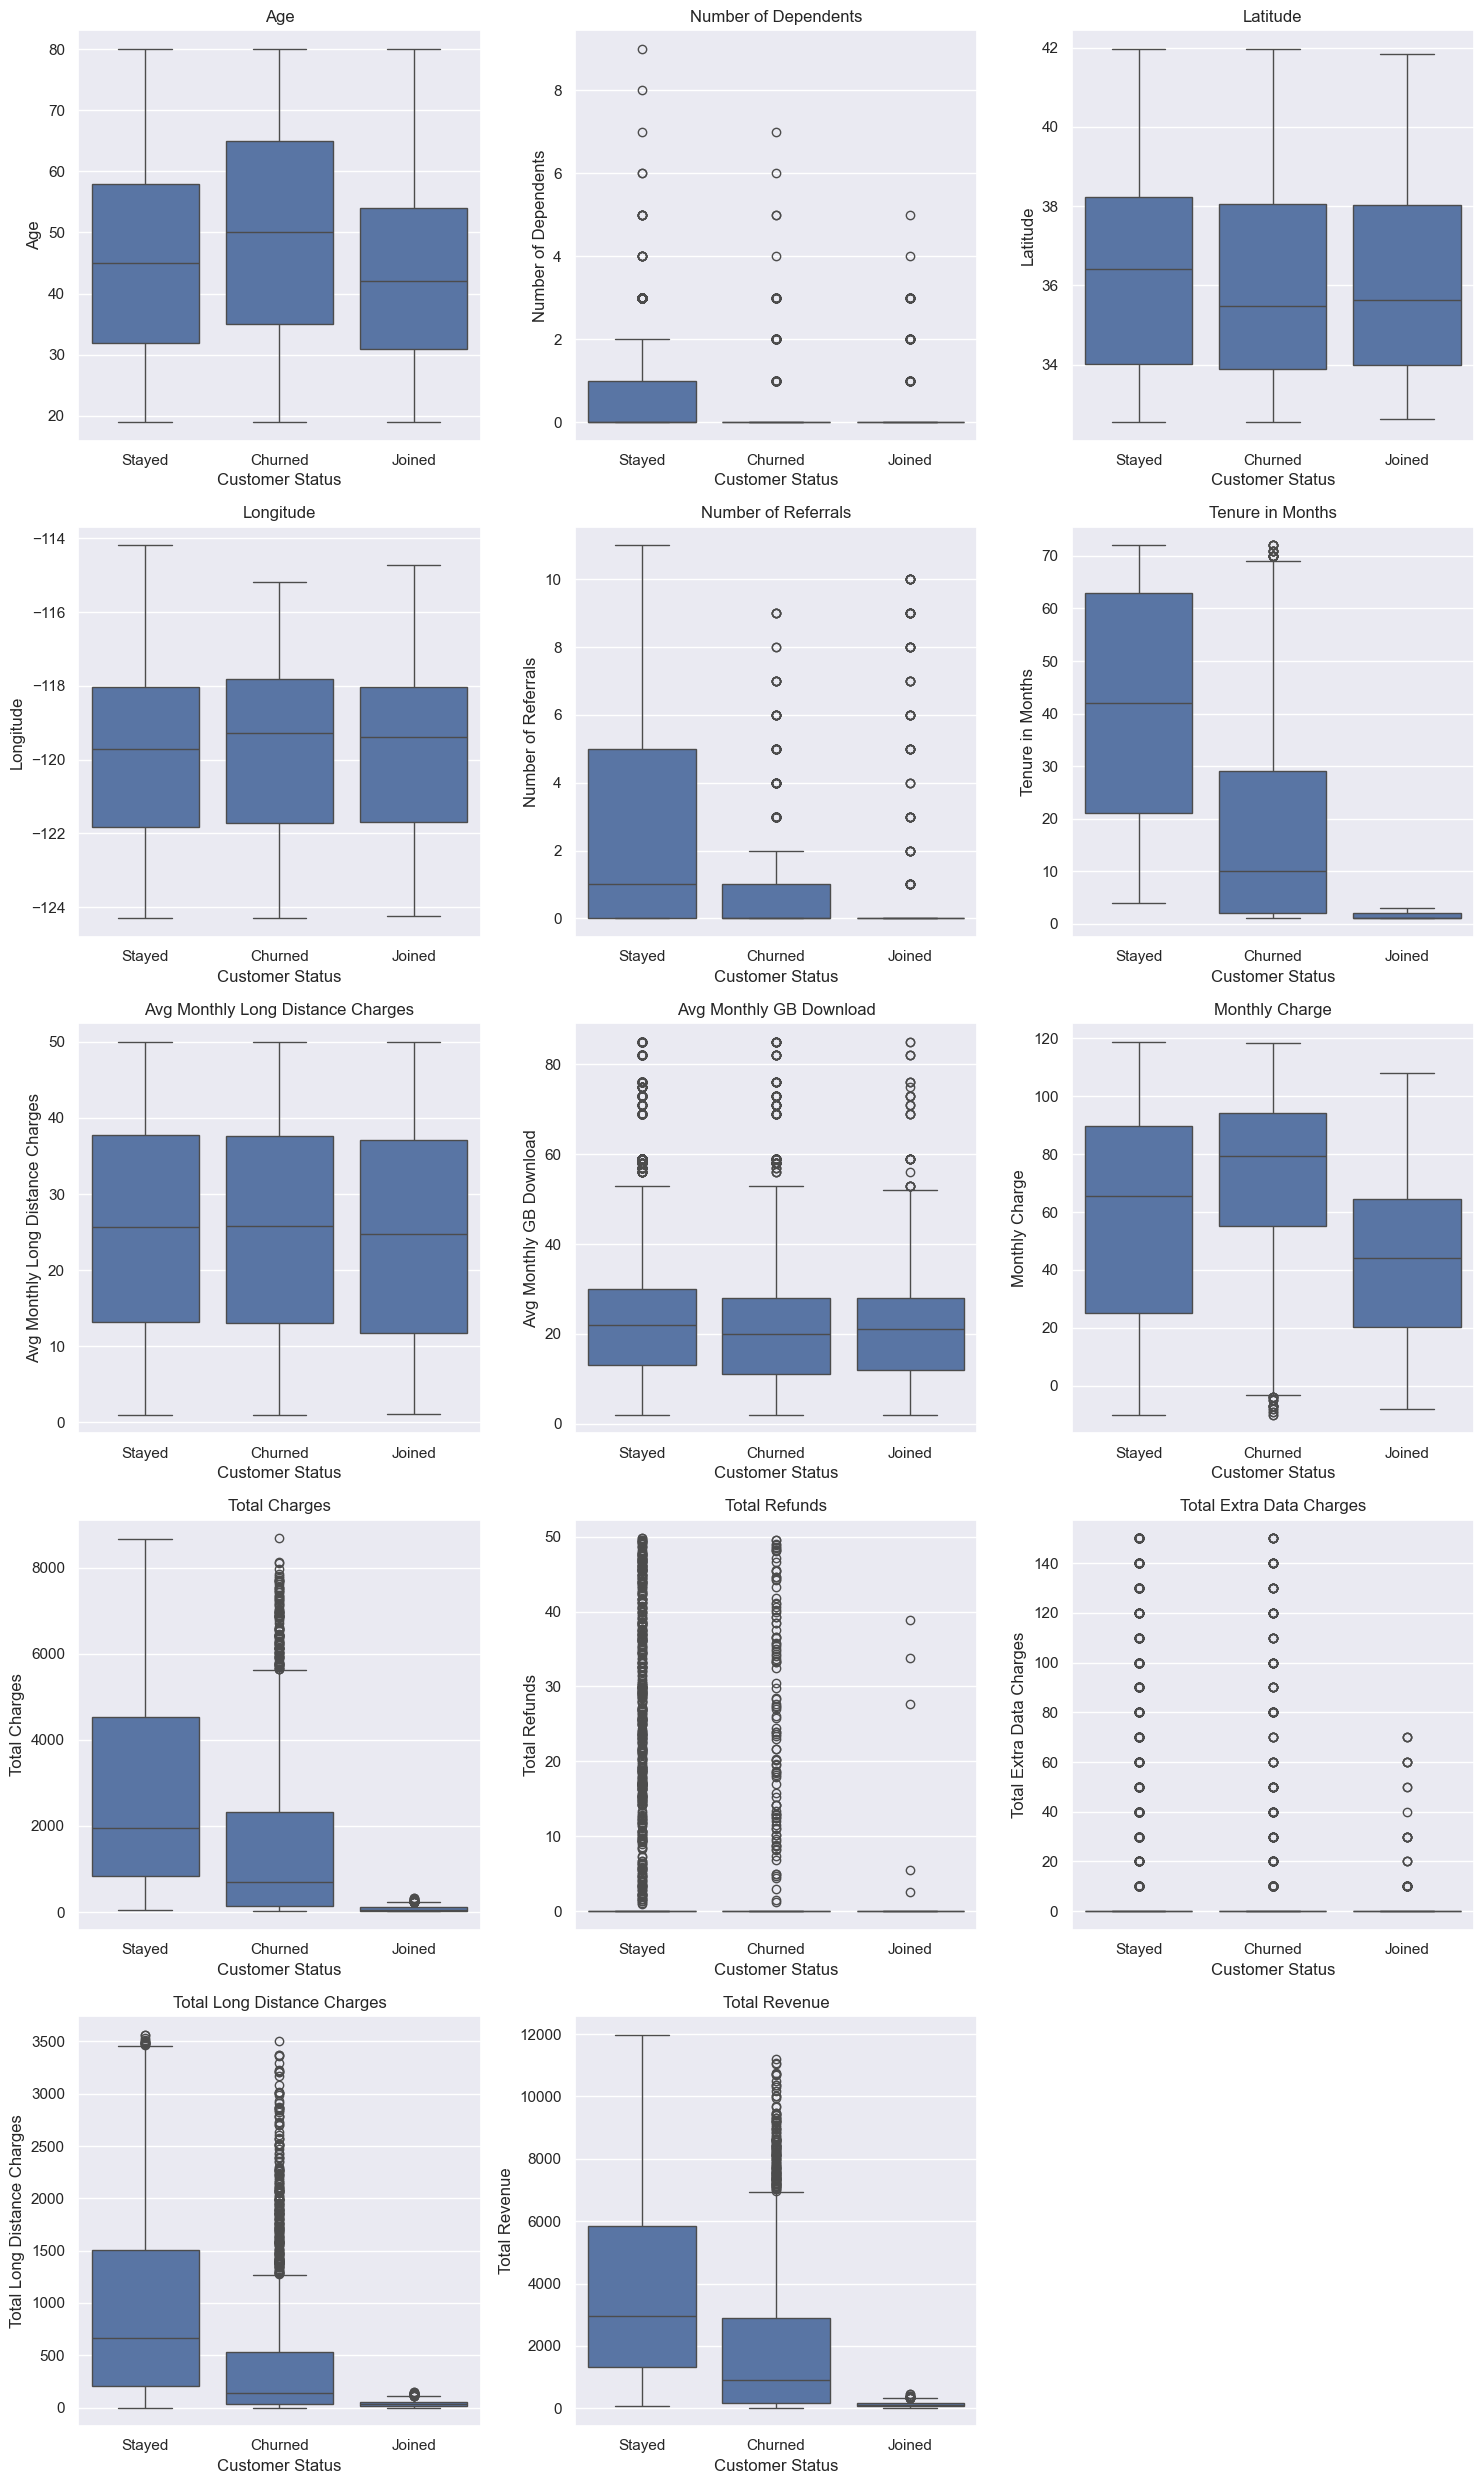

In [247]:
# Get the names of all the columns with data type " int "
int_vars = data.select_dtypes(include=['int','float']).columns.tolist()

# Create w subplot with subplots
num_cols = len(int_vars)
num_rows = (num_cols + 2)//3
fig, axs = plt.subplots(nrows=num_rows, ncols=3, figsize=(15,5*num_rows))
axs = axs.flatten()

# create a box plot for each numerical variables using seaborn
for i, var in enumerate(int_vars):
    sns.boxplot(y=var, x='Customer Status', data=data, ax=axs[i])
    axs[i].set_title(var)

# Remove any extra empty subplots if needed
if num_cols < len(axs):
    for i in range(num_cols, len(axs)):
        fig.delaxes(axs[i])

# Adjust spacing between subplots
fig.tight_layout()

# Show plot
plt.show()

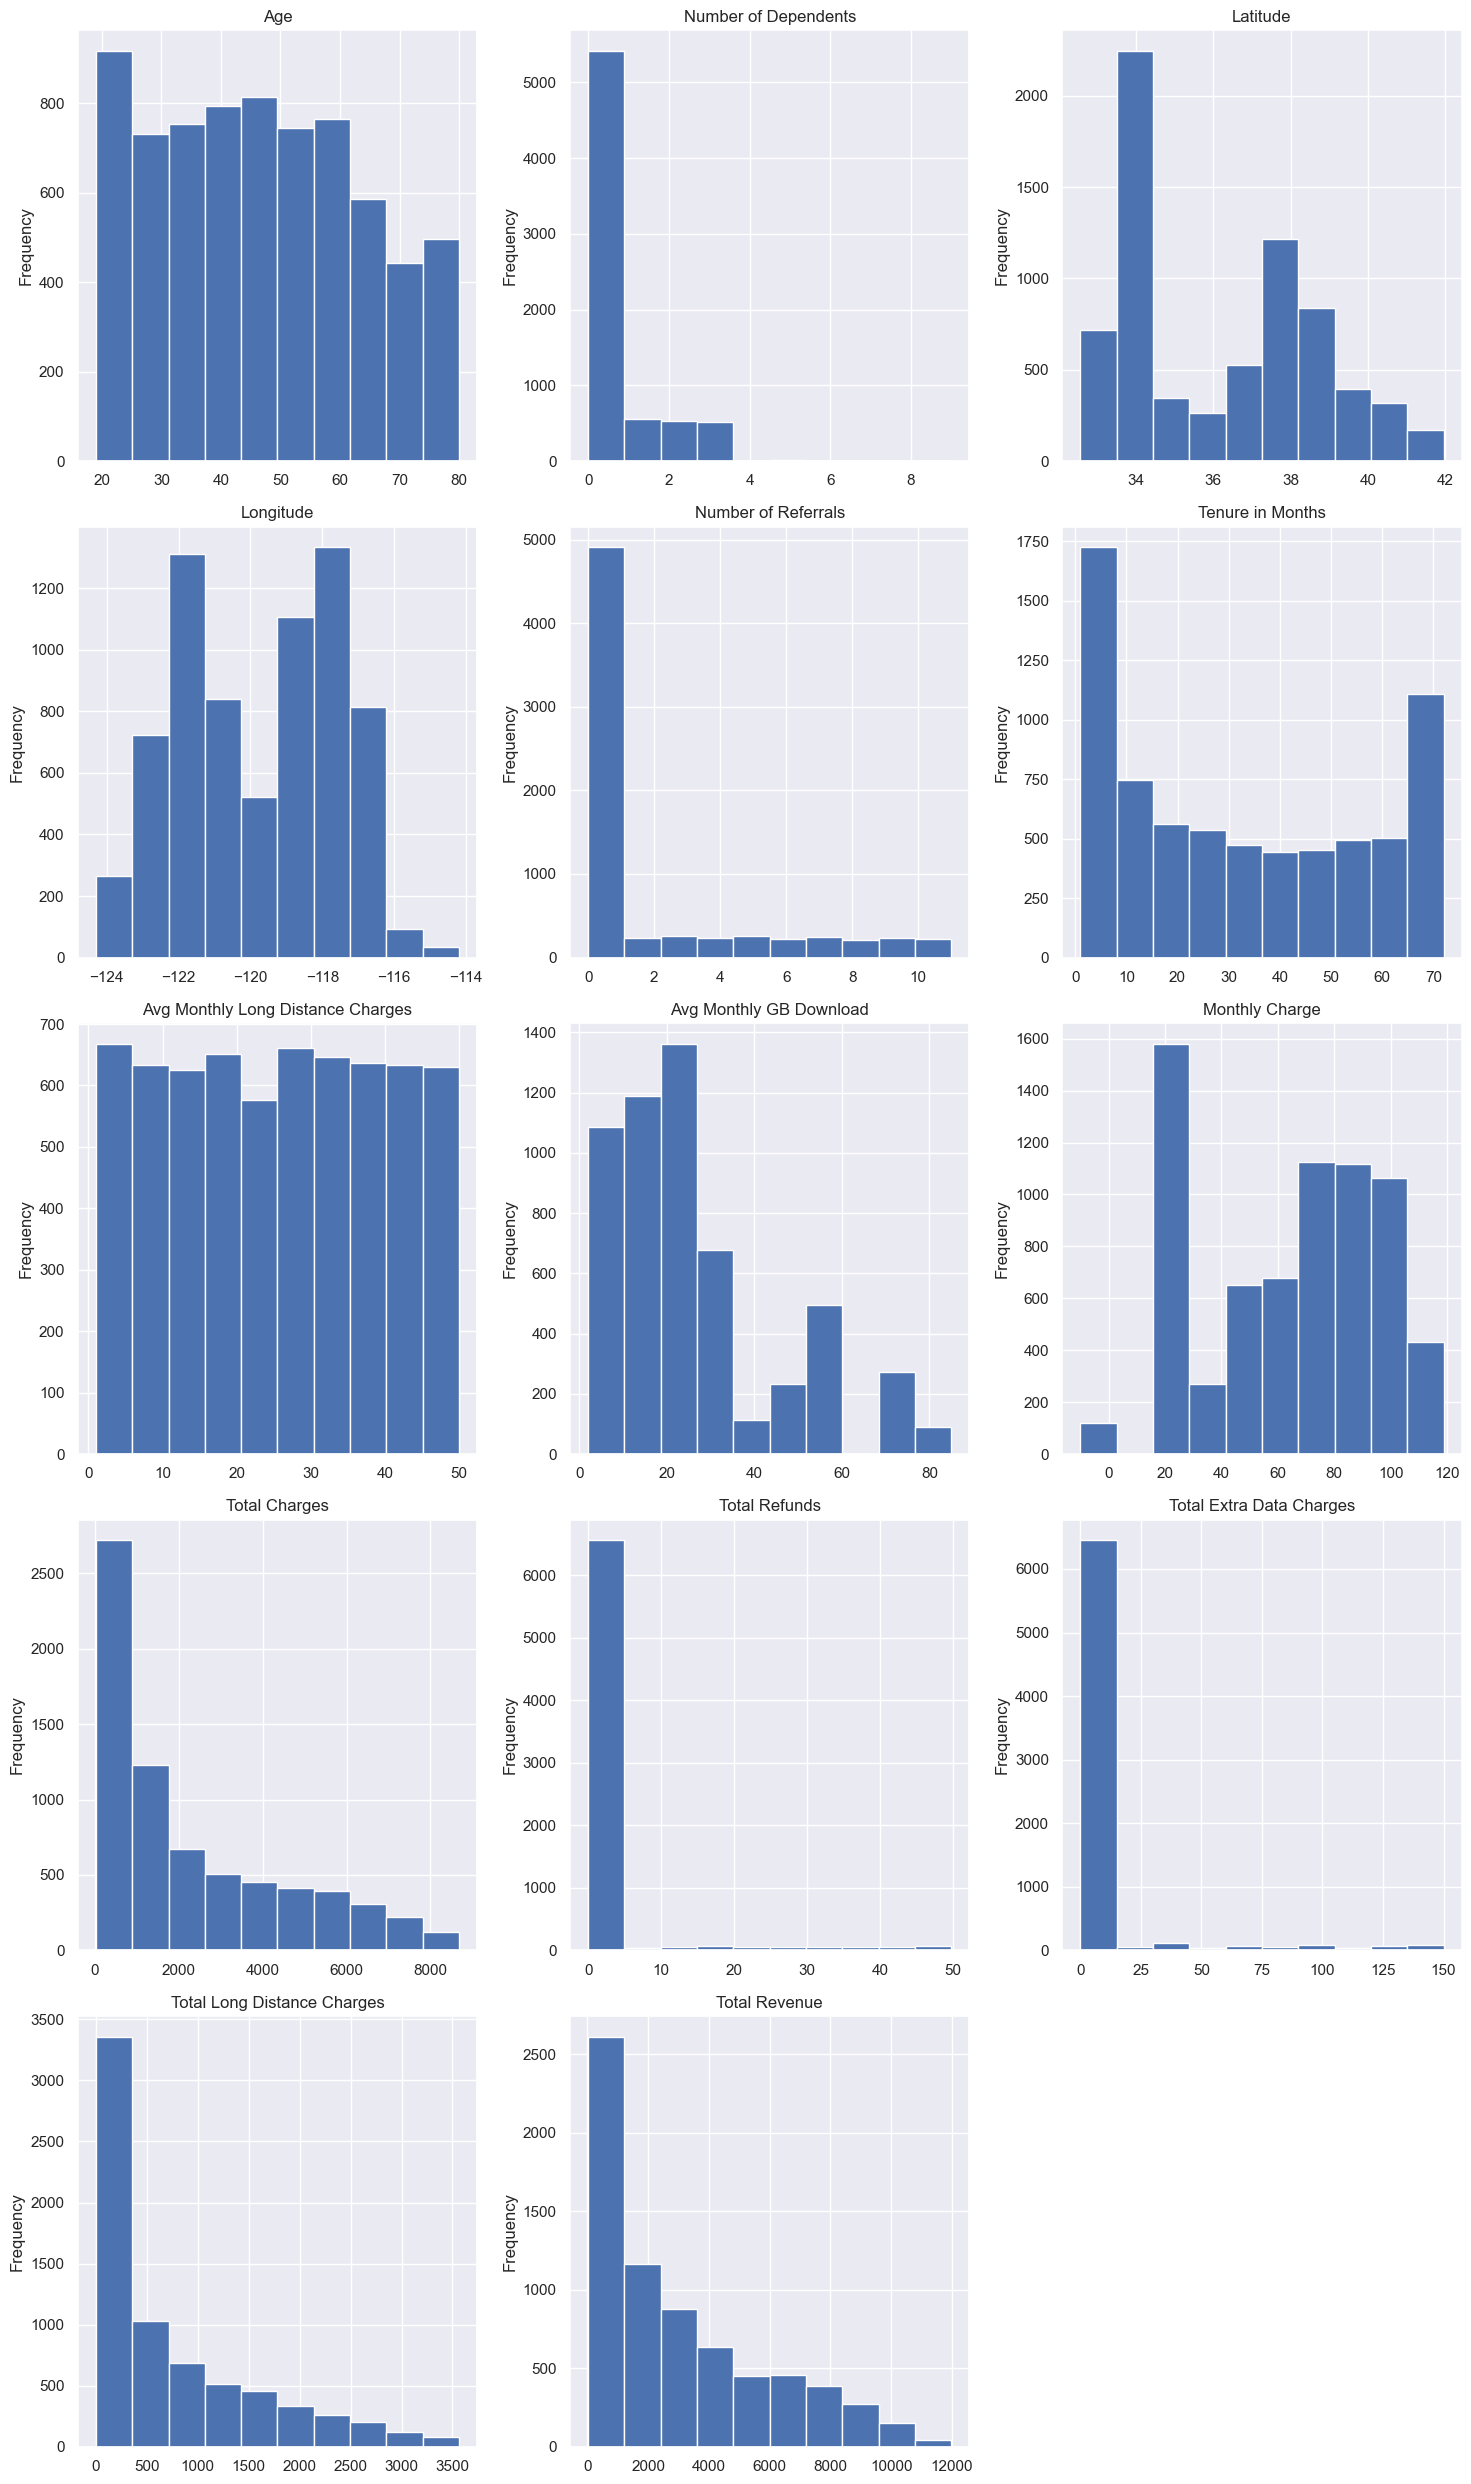

In [248]:
# Get the names of all the columns with data type " int "
int_vars = data.select_dtypes(include=['int','float']).columns.tolist()

# Create w subplot with subplots
num_cols = len(int_vars)
num_rows = (num_cols + 2)//3
fig, axs = plt.subplots(nrows=num_rows, ncols=3, figsize=(15,5*num_rows))
axs = axs.flatten()

# create a histogram for each numerical variables
for i, var in enumerate(int_vars):
    data[var].plot.hist(ax=axs[i])
    axs[i].set_title(var)

# Remove any extra empty subplots if needed
if num_cols < len(axs):
    for i in range(num_cols, len(axs)):
        fig.delaxes(axs[i])

# Adjust spacing between subplots
fig.tight_layout()

# Show plot
plt.show()

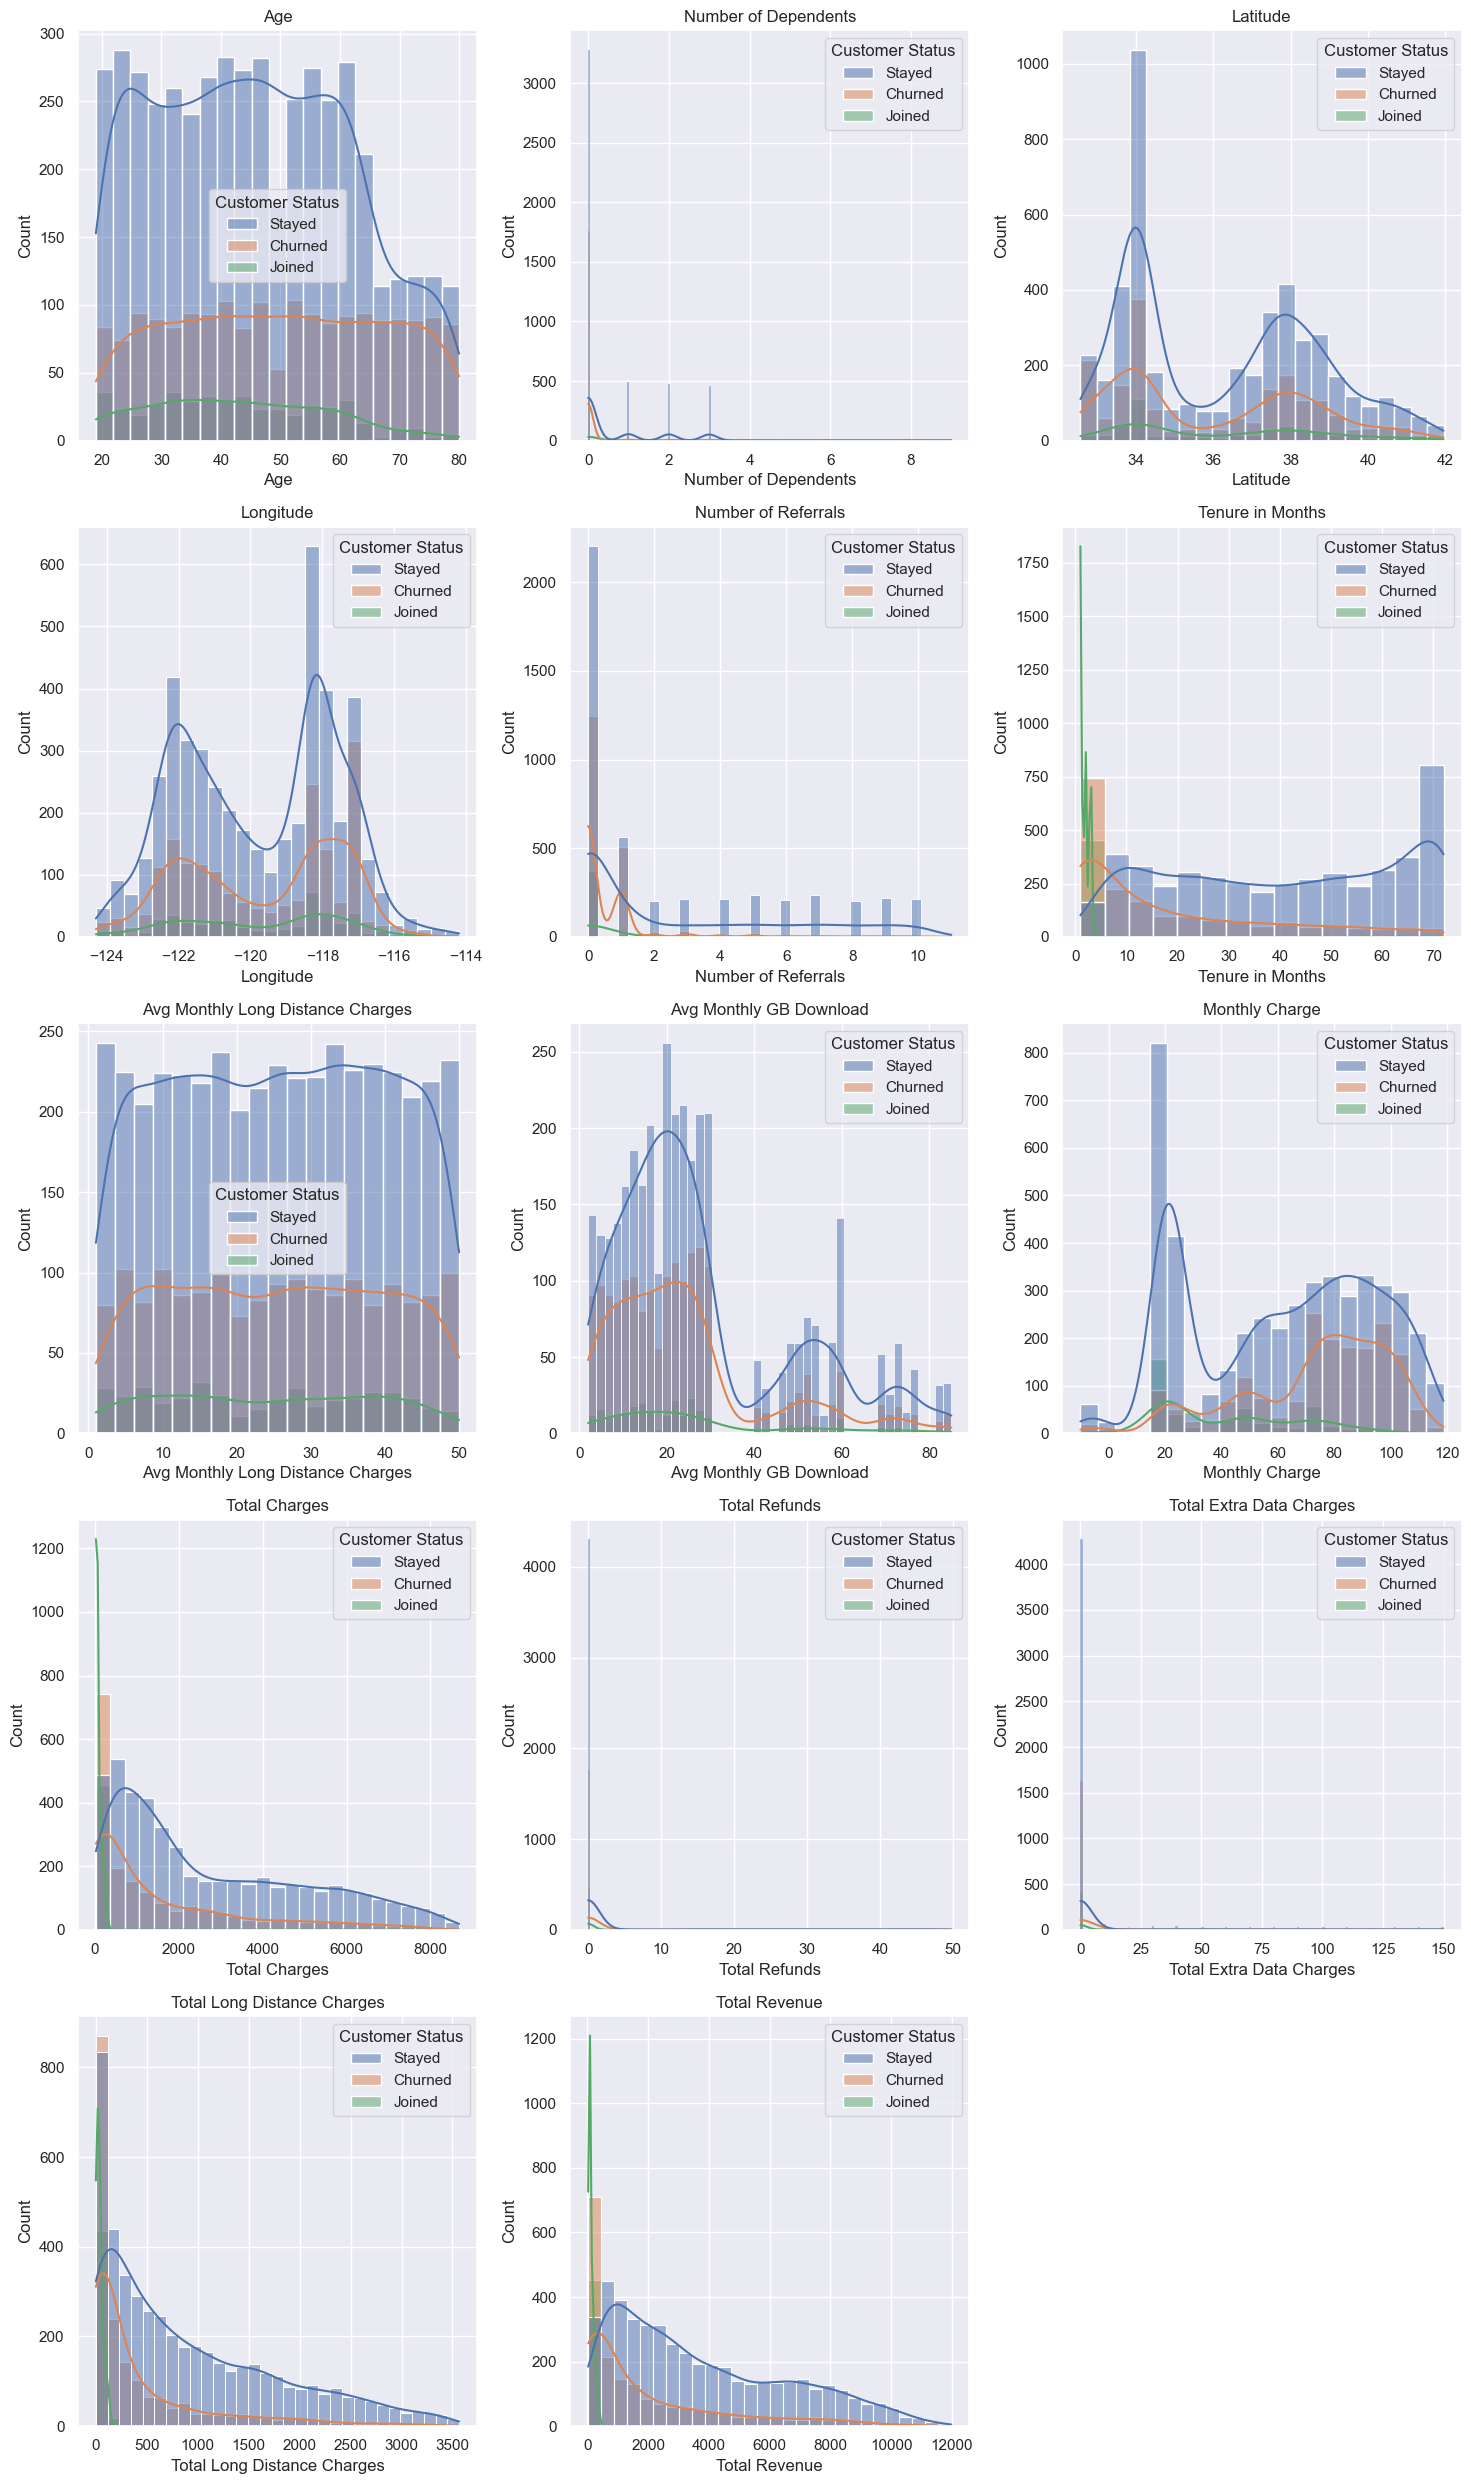

In [249]:
# Get the names of all the columns with data type " int "
int_vars = data.select_dtypes(include=['int','float']).columns.tolist()

# Create w subplot with subplots
num_cols = len(int_vars)
num_rows = (num_cols + 2)//3
fig, axs = plt.subplots(nrows=num_rows, ncols=3, figsize=(15,5*num_rows))
axs = axs.flatten()

# create a Histogram for each integer variables using seaborn hue = 'Attrition'
for i, var in enumerate(int_vars):
    sns.histplot(data=data, x=var,hue='Customer Status',kde=True, ax=axs[i])
    axs[i].set_title(var)

# Remove any extra empty subplots if needed
if num_cols < len(axs):
    for i in range(num_cols, len(axs)):
        fig.delaxes(axs[i])

# Adjust spacing between subplots
fig.tight_layout()

# Show plot
plt.show()

C:\Users\SIDDESH R M\AppData\Local\Temp\ipykernel_10984\2833845992.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(),rotation=90)
C:\Users\SIDDESH R M\AppData\Local\Temp\ipykernel_10984\2833845992.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(),rotation=90)
C:\Users\SIDDESH R M\AppData\Local\Temp\ipykernel_10984\2833845992.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(),rotation=90)
C:\Users\SIDDESH R M\AppData\Local\Temp\ipykernel_10984\2833845992.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

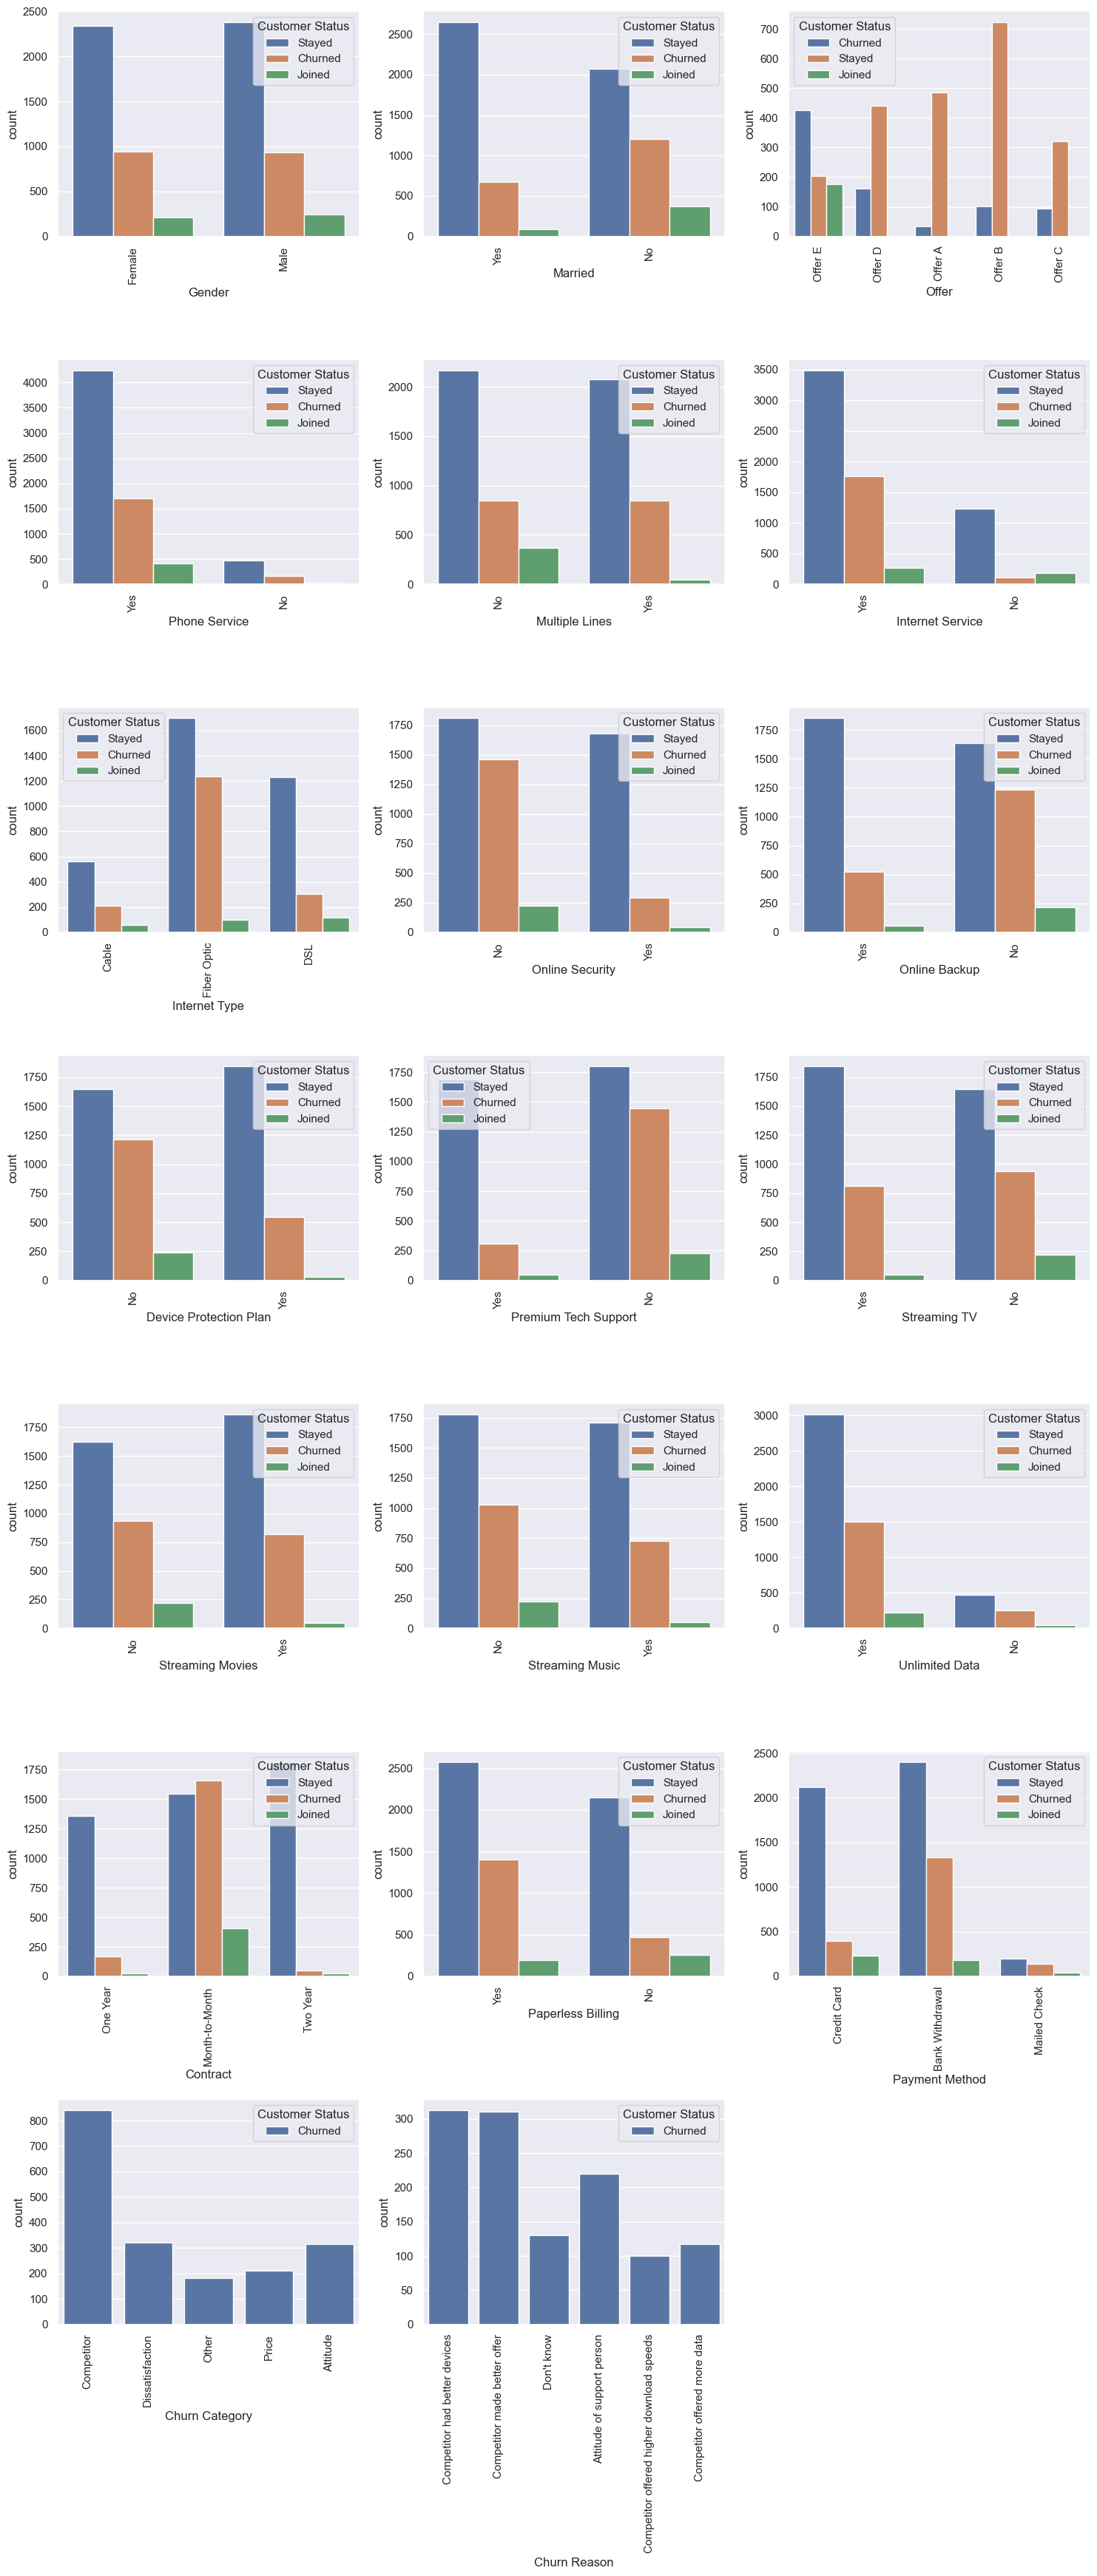

In [250]:
# Get the names of all the columns with data type " object "
cat_vars = data.select_dtypes(include=['object']).columns.tolist()

# Exclude 'Attrition from the list if it exists in cat_vars
if 'Customer Status' in cat_vars:
    cat_vars.remove('Customer Status')

# Create a subplot with subplots
num_cols = len(cat_vars)
num_rows = (num_cols + 2)//3
fig, axs = plt.subplots(nrows=num_rows, ncols=3, figsize=(15,5*num_rows))
axs = axs.flatten()

# create a Count plot for the top 6 values of each categorical variable
for i, var in enumerate(cat_vars):
    top_values = data[var].value_counts().nlargest(6).index
    filtered_df = data[data[var].isin(top_values)]
    sns.countplot(data=filtered_df, x=var,hue='Customer Status', ax=axs[i])
    axs[i].set_xticklabels(axs[i].get_xticklabels(),rotation=90)

# Remove any extra empty subplots if needed
for i in range(num_cols, len(axs)):
    fig.delaxes(axs[i])

# Adjust spacing between subplots
fig.tight_layout()

# Show plot
plt.show()

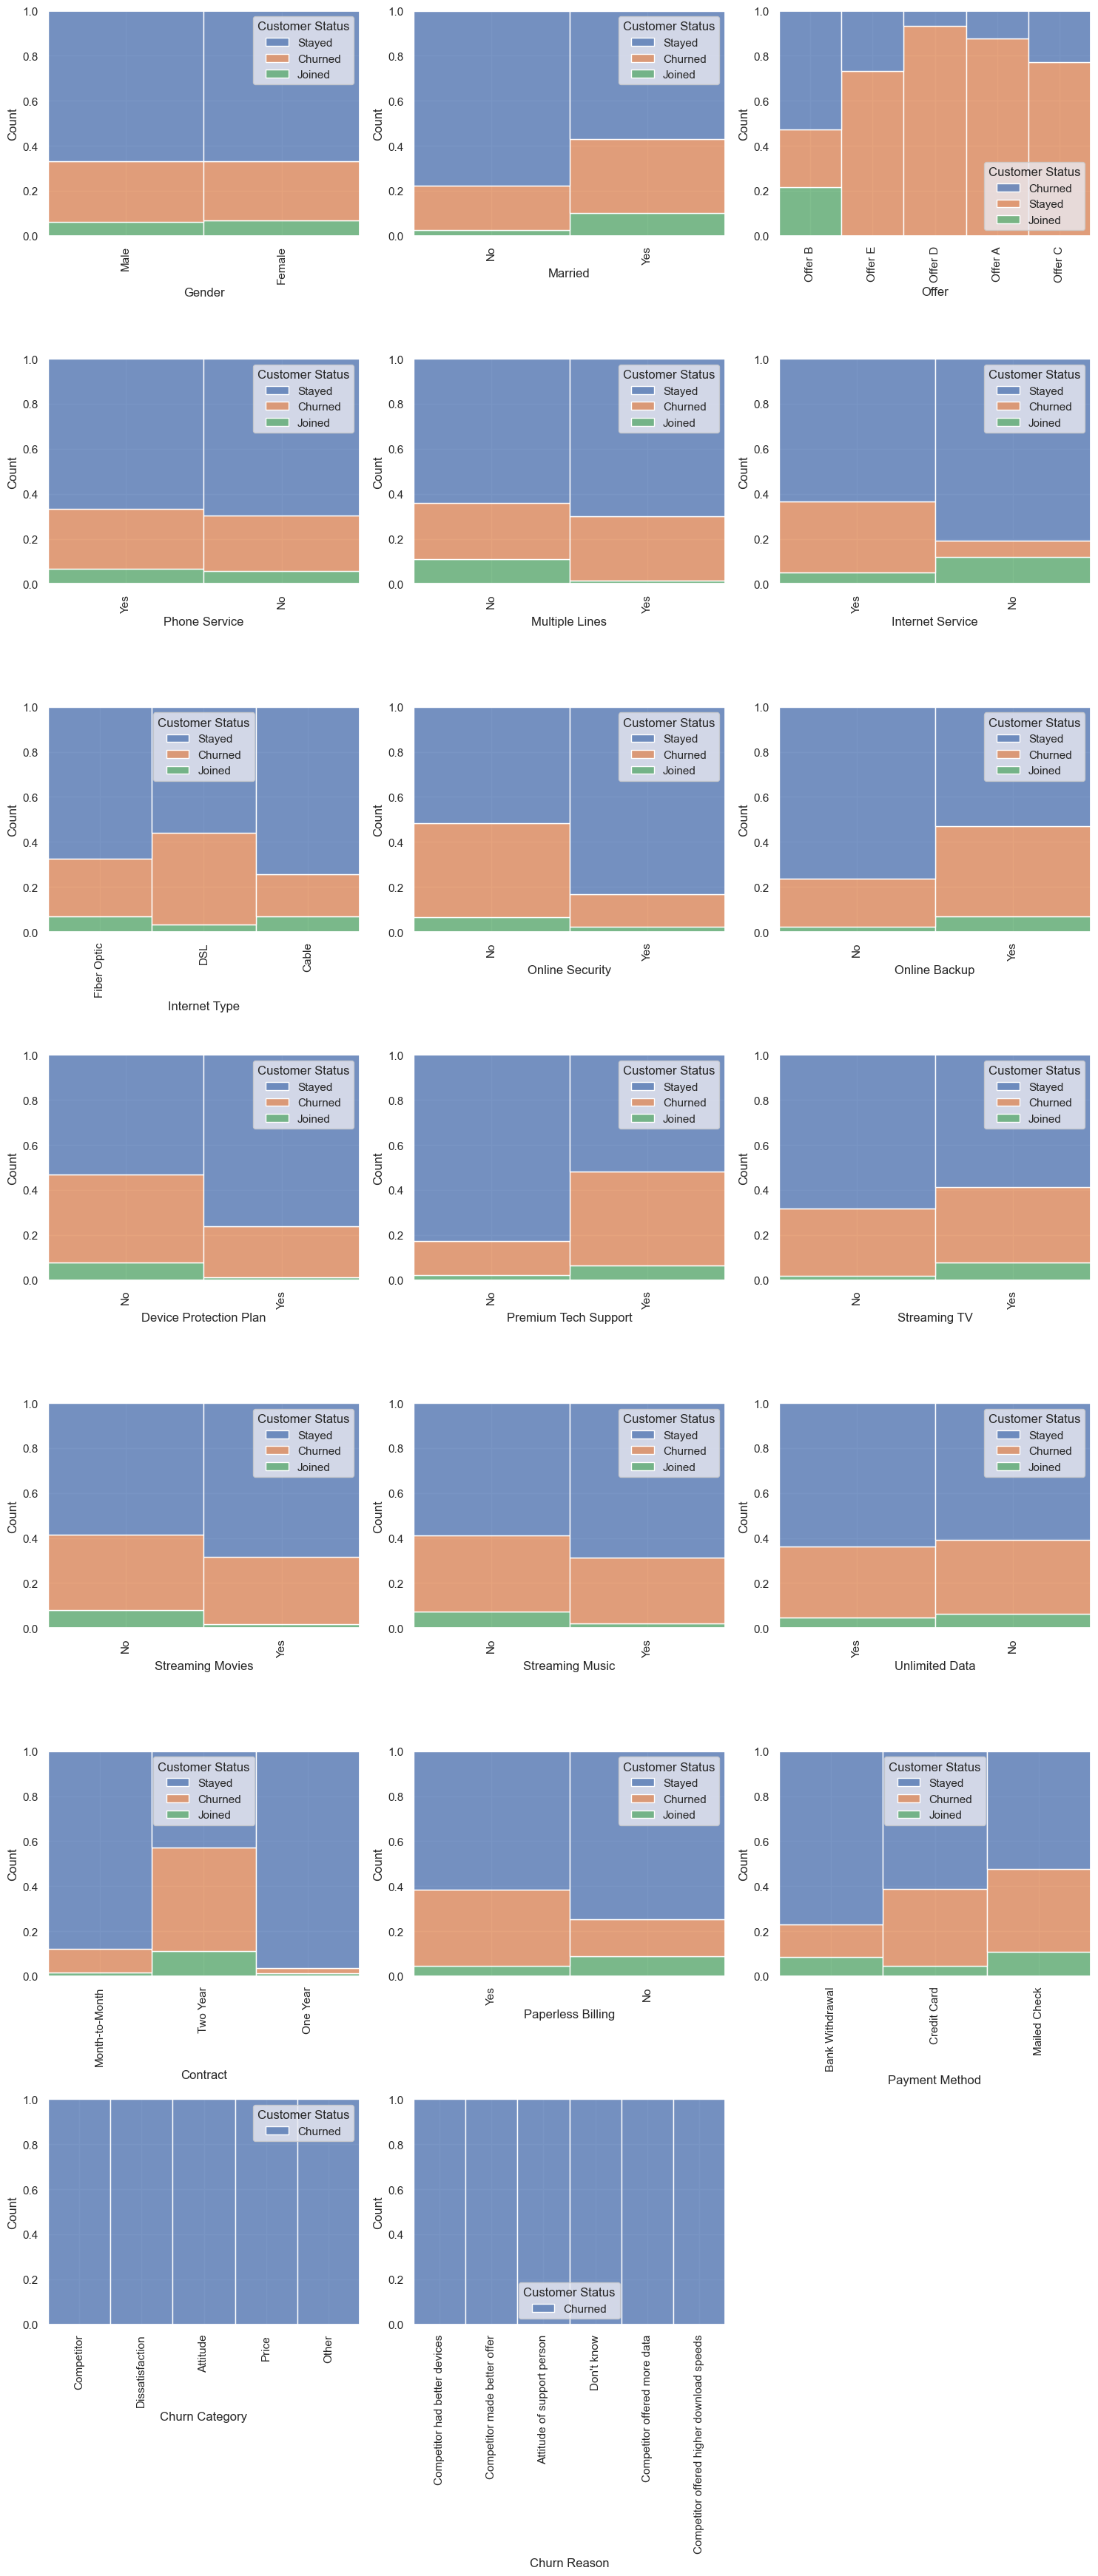

In [251]:
# Get the names of all the columns with data type " object "
cat_vars = data.select_dtypes(include=['object']).columns.tolist()

# Exclude 'Attrition from the list if it exists in cat_vars
if 'Customer Status' in cat_vars:
    cat_vars.remove('Customer Status')

# Create a subplot with subplots
num_cols = len(cat_vars)
num_rows = (num_cols + 2)//3
fig, axs = plt.subplots(nrows=num_rows, ncols=3, figsize=(15,5*num_rows))
axs = axs.flatten()

# create a Count plot for the top 6 values of each categorical variable
for i, var in enumerate(cat_vars):
    top_values = data[var].value_counts().nlargest(6).index
    filtered_df = data[data[var].isin(top_values)]

    # Set x-tick positions explicitly
    tick_positions = range(len(top_values))
    axs[i].set_xticks(tick_positions)
    axs[i].set_xticklabels(top_values,rotation=90)      # set x-ticks labels

    sns.histplot(data=filtered_df, x=var,hue='Customer Status', ax=axs[i], multiple="fill", kde=False, element="bars", fill=True)
    axs[i].set_xlabel(var)

    
# Remove any extra empty subplots if needed
for i in range(num_cols, len(axs)):
    fig.delaxes(axs[i])

# Adjust spacing between subplots
fig.tight_layout()

# Show plot
plt.show()

AttributeError: 'Series' object has no attribute 'append'

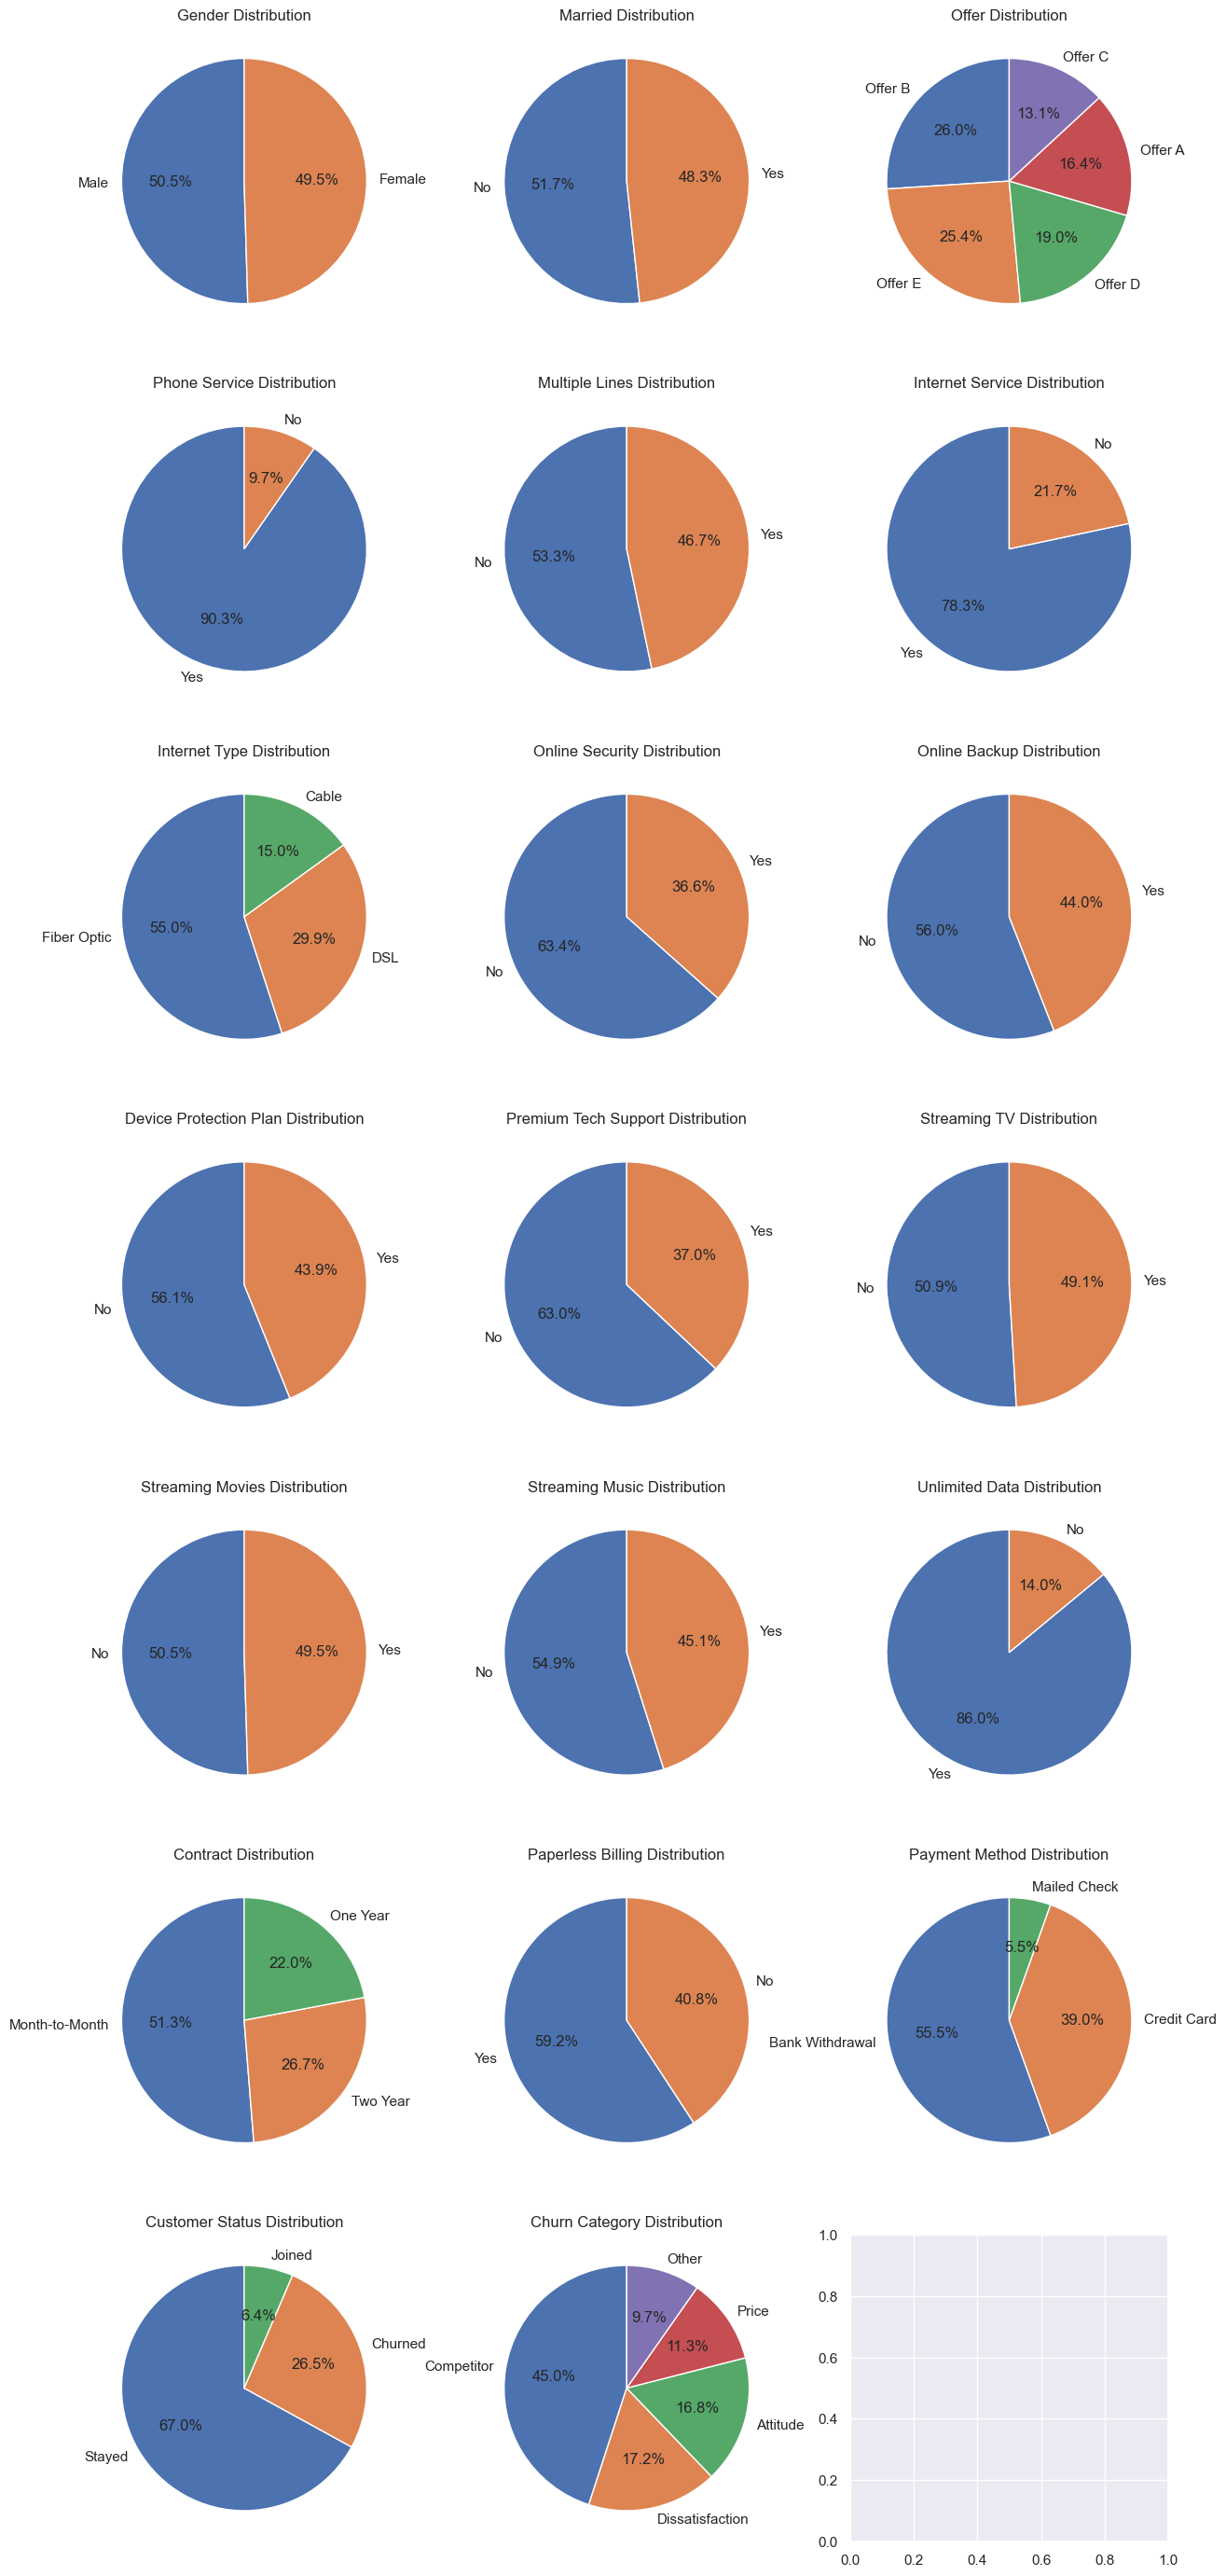

In [252]:
# Specify the maximum number of categories to show induvidually
max_categories = 5

# Filter categorical column with "object" data type
cat_cols = [col for col in data.columns if col != 'y' and data[col].dtype == 'object']

# Create a figure with subplots
num_cols = len(cat_vars)
num_rows = (num_cols + 2)//3
fig, axs = plt.subplots(nrows=num_rows, ncols=3, figsize=(15,5*num_rows))

# Flatten the axs arry for easier indexing
axs = axs.flatten()

# Create a pie chart for each categorical column
for i, col in enumerate(cat_cols):
    if i < len(axs):
        # Count the number of occurrences for each category
        cat_counts = data[col].value_counts()

        # Group categories beyond the top max_categories as 'other'
        if len(cat_counts) > max_categories:
            cat_counts_top = cat_counts[:max_categories]
            cat_counts_other = pd.Series(cat_counts[max_categories:].sum(), index=['Other'])
            cat_counts = cat_counts_top.append(cat_counts_other)

        # Create a pie chart
        axs[i].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=90)
        axs[i].set_title(f'{col} Distribution')

# Remove any extra empty subplots if needed
if num_cols < len(axs):
    for i in range(num_cols, len(axs)):
        fig.delaxes(axs[i])

# Adjust spacing between subplots
fig.tight_layout()

# Show plot
plt.show()

**Data Preprocessing Part 2**

In [253]:
# Check the amount of missing value
check_missing = data.isnull().sum() * 100/ data.shape[0]
check_missing[check_missing > 0].sort_values(ascending=False)

Churn Category                       73.463013
Churn Reason                         73.463013
Offer                                55.047565
Internet Type                        21.666903
Avg Monthly GB Download              21.666903
Online Security                      21.666903
Online Backup                        21.666903
Device Protection Plan               21.666903
Premium Tech Support                 21.666903
Streaming TV                         21.666903
Streaming Movies                     21.666903
Streaming Music                      21.666903
Unlimited Data                       21.666903
Avg Monthly Long Distance Charges     9.683374
Multiple Lines                        9.683374
dtype: float64

In [254]:
# Drop column with missing value more than 25%
data.drop(columns = ['Churn Category','Churn Reason'], inplace=True)
data.shape

(7043, 33)

In [255]:
# Check the amount of missing value
check_missing = data.isnull().sum() * 100/ data.shape[0]
check_missing[check_missing > 0].sort_values(ascending=False)

Offer                                55.047565
Internet Type                        21.666903
Avg Monthly GB Download              21.666903
Online Security                      21.666903
Online Backup                        21.666903
Device Protection Plan               21.666903
Premium Tech Support                 21.666903
Streaming TV                         21.666903
Streaming Movies                     21.666903
Streaming Music                      21.666903
Unlimited Data                       21.666903
Avg Monthly Long Distance Charges     9.683374
Multiple Lines                        9.683374
dtype: float64

In [256]:
data.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'Latitude',
       'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status'],
      dtype='object')

In [257]:
# Drop column with 21% missing vlaue because they are in the same user that have missing value
subset_columns = ['Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data']
data.dropna(subset=subset_columns, inplace=True)

# I just drop the missing values
# If you want to impute you can impute

In [258]:
data.shape

(5517, 33)

In [259]:
# Drop column with 9% missing value because they are in the same users that have missing value
subset_columns = ['Avg Monthly Long Distance Charges', 'Multiple Lines']
data.dropna(subset=subset_columns, inplace=True)
data.shape

(4835, 33)

In [260]:
# Check again the amount of missing value
check_missing = data.isnull().sum() * 100/ data.shape[0]
check_missing[check_missing > 0].sort_values(ascending=False)

# In the output there no missing values, u can see the output

Offer    54.622544
dtype: float64

In [261]:
# Multi classification or Bi classification
data['Customer Status'].value_counts()

Customer Status
Stayed     3015
Churned    1586
Joined      234
Name: count, dtype: int64

In [262]:
# Change Joined into stayed, so we can make binary classification
# replace all values in the 'Customer Status' column with 'Stayed'
data['Customer Status'] = data['Customer Status'].replace('Joined','Stayed')
data['Customer Status'].value_counts()

Customer Status
Stayed     3249
Churned    1586
Name: count, dtype: int64

**Label Encoding for Object Datatypes**

In [263]:
# Loop over each column in the Dataframe where dtype is 'object'
for col in data.select_dtypes(include=['object']).columns:

    # print the column name and the unique values
    print(f"{col}: {data[col].unique()}")

Gender: ['Female' 'Male']
Married: ['Yes' 'No']
Offer: [nan 'Offer E' 'Offer D' 'Offer A' 'Offer B' 'Offer C']
Phone Service: ['Yes']
Multiple Lines: ['No' 'Yes']
Internet Service: ['Yes']
Internet Type: ['Cable' 'Fiber Optic' 'DSL']
Online Security: ['No' 'Yes']
Online Backup: ['Yes' 'No']
Device Protection Plan: ['No' 'Yes']
Premium Tech Support: ['Yes' 'No']
Streaming TV: ['Yes' 'No']
Streaming Movies: ['No' 'Yes']
Streaming Music: ['No' 'Yes']
Unlimited Data: ['Yes' 'No']
Contract: ['One Year' 'Month-to-Month' 'Two Year']
Paperless Billing: ['Yes' 'No']
Payment Method: ['Credit Card' 'Bank Withdrawal' 'Mailed Check']
Customer Status: ['Stayed' 'Churned']


In [264]:
from sklearn import preprocessing

# Loop over each column in the Dataframe where dtype is "object"
for col in data.select_dtypes(include=['object']).columns:

    # Initicalize a LabelEncoder onject
    label_encoder = preprocessing.LabelEncoder()

    # Fit the encoder to the unique values in the column
    label_encoder.fit(data[col].unique())

    # Transform the column using the encoder
    data[col] = label_encoder.transform(data[col])

    # Print the column name and the uniq encoded values
    print(f'{col}: {data[col].unique()}')

Gender: [0 1]
Married: [1 0]
Offer: [5 4 3 0 1 2]
Phone Service: [0]
Multiple Lines: [0 1]
Internet Service: [0]
Internet Type: [0 2 1]
Online Security: [0 1]
Online Backup: [1 0]
Device Protection Plan: [0 1]
Premium Tech Support: [1 0]
Streaming TV: [1 0]
Streaming Movies: [0 1]
Streaming Music: [0 1]
Unlimited Data: [1 0]
Contract: [1 0 2]
Paperless Billing: [1 0]
Payment Method: [1 0 2]
Customer Status: [1 0]


In [265]:
# Now

# Customer Status: ['Stayed','Churned']
# Customer Status: [1 0]

<Axes: >

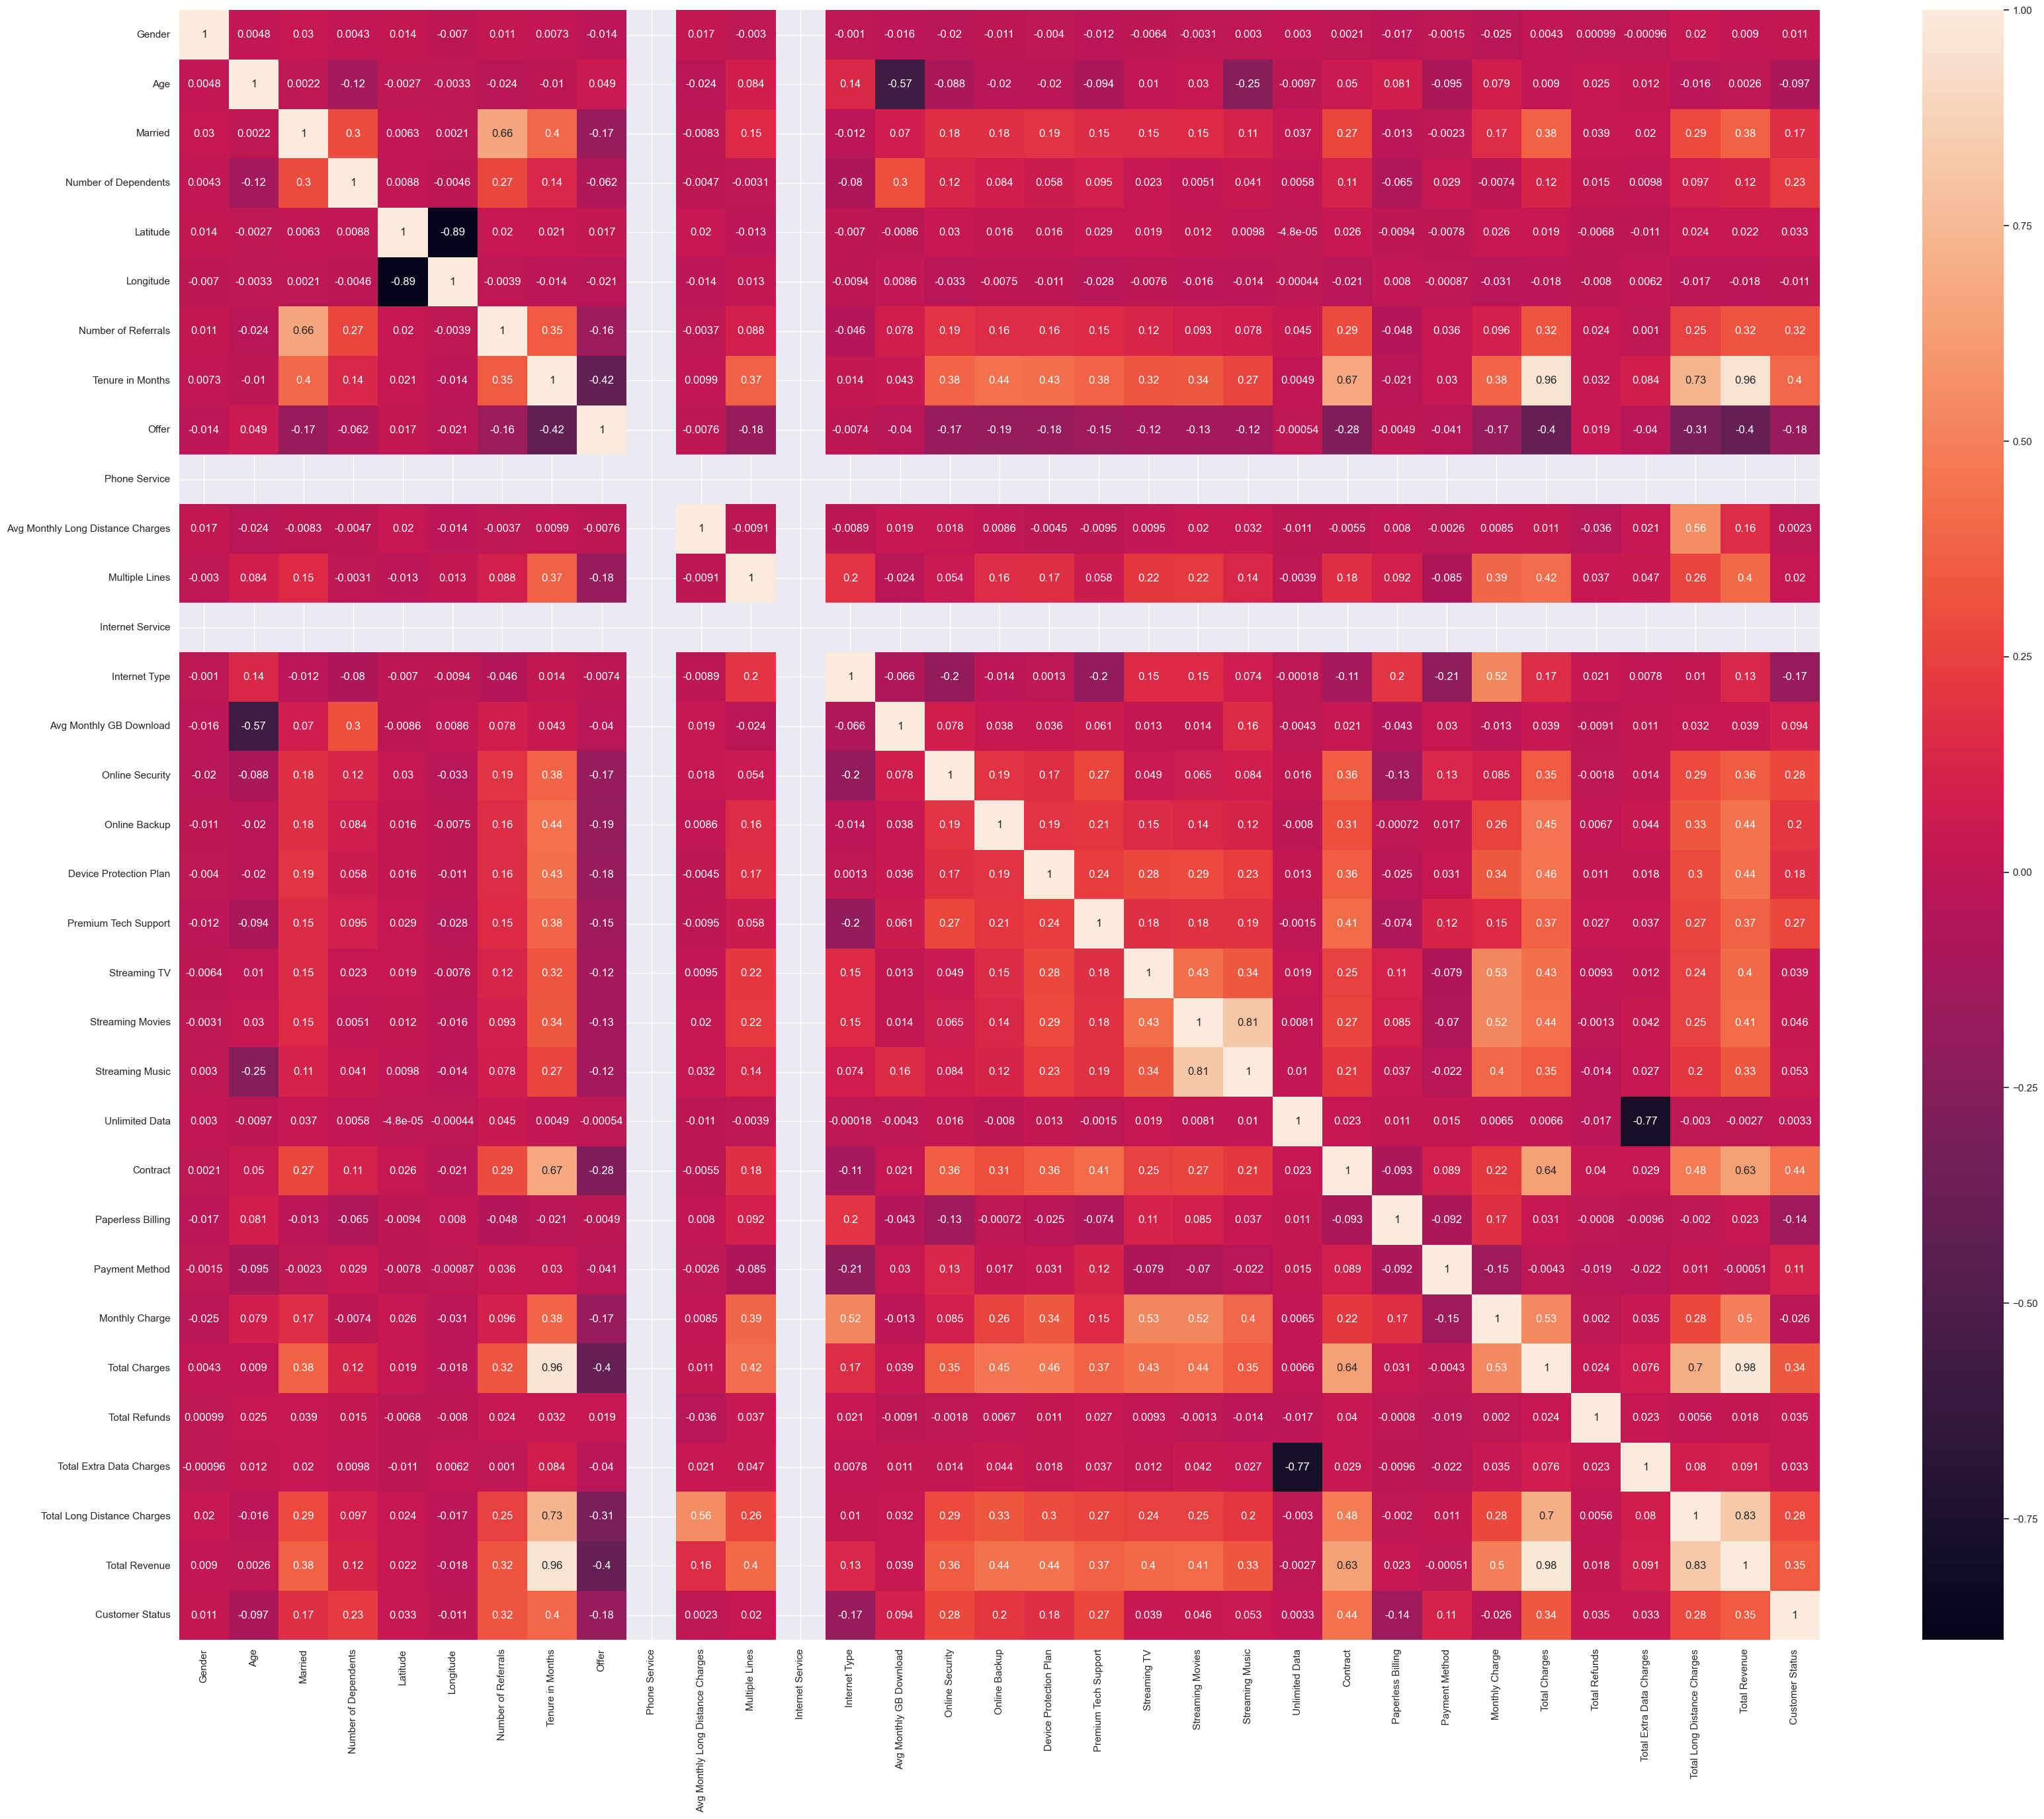

In [266]:
# Correlation Heatmap
plt.figure(figsize=(40, 32))
sns.heatmap(data.corr(), fmt='.2g', annot=True)

In [267]:
# Remove Internet Service and Phone Service column because of zero correlation   u can see that in above heatmap
data.drop(columns = ['Internet Service','Phone Service'],inplace=True)
data.shape

(4835, 31)

In [268]:
data.to_csv("Preprocessed_data.csv")